```text id="kld1yb"
✅ 1. Project Setup & Imports
✅ 2. Load Config & LLM
✅ 3. Verify LLM Connection
✅ 4. Import LangGraph Components
✅ 5. Understand GraphState
✅ 6. Create First Node
✅ 7. Test First Node
✅ 8. Create StateGraph
✅ 9. Add Node to Graph
✅ 10. Add START and END Edges
✅ 11. Compile Graph
✅ 12. Invoke Graph
✅ 13. Visualize Graph Structure
✅ 14. Understand State Updates
✅ 15. Final Recap
```

In [5]:
# ==========================================
# Notebook 1: LangGraph Basics
# Project Setup & Imports
# ==========================================

import os
import sys
import warnings

warnings.filterwarnings("ignore")

PROJECT_ROOT = os.path.abspath("..")

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

print("Project Root Added Successfully")
print(PROJECT_ROOT)

Project Root Added Successfully
d:\projects\python\stepIntoAI\LangGraph-Crash-Course


In [6]:
# ==========================================
# Load Configuration & LLM
# ==========================================

from src.utils.config_loader import load_config
from src.utils.model_loader import load_llm

config = load_config()

llm = load_llm()

print("Configuration Loaded Successfully")
print("LLM Loaded Successfully")
print(type(llm))

OpenAIError: The api_key client option must be set either by passing api_key to the client or by setting the OPENAI_API_KEY environment variable

In [3]:
# ==========================================
# Verify LLM Connection
# ==========================================

response = llm.invoke("What is LangGraph in one sentence?")
print(response.content)

LangGraph is a framework designed to facilitate the creation and management of complex language models and workflows by integrating various natural language processing tools and techniques.


In [ ]:
# ==========================================
# Import LangGraph Components
# ==========================================

from langgraph.graph import StateGraph
from langgraph.graph import START
from langgraph.graph import END


print("LangGraph Components Imported Successfully")
print("StateGraph:", StateGraph)
print("START:", START)
print("END:", END)

LangGraph Components Imported Successfully
StateGraph: <class 'langgraph.graph.state.StateGraph'>
START: __start__
END: __end__


In [5]:
# ==========================================
# Understanding GraphState
# ==========================================

from src.states.state_schema import GraphState

sample_state = GraphState(
    user_query="What is LangGraph?",
    keywords=[],
    research_notes="",
    summary="",
    next_step="",
    review_feedback=""
)

print(sample_state)

{'user_query': 'What is LangGraph?', 'keywords': [], 'research_notes': '', 'summary': '', 'next_step': '', 'review_feedback': ''}


In [6]:
# ==========================================
# Create First Node
# ==========================================

def research_node(state: GraphState):
    print("\n--- Research Node Executed ---")
    return {
        "research_notes":
        f"Research completed for: {state['user_query']}"}
        
print("Research Node Created Successfully")

Research Node Created Successfully


In [7]:
# ==========================================
# Test First Node
# ==========================================

test_state = {"user_query": "What is LangGraph?"}
result = research_node(test_state)

print("\nNode Output:\n")
print(result)


--- Research Node Executed ---

Node Output:

{'research_notes': 'Research completed for: What is LangGraph?'}


In [8]:
# ==========================================
# Create StateGraph
# ==========================================

builder = StateGraph(GraphState)

print("StateGraph Created Successfully")
print(type(builder))

StateGraph Created Successfully
<class 'langgraph.graph.state.StateGraph'>


In [9]:
# ==========================================
# Add Node to Graph
# ==========================================

builder.add_node("research_node",research_node)
print("Node Added Successfully")

Node Added Successfully


In [10]:
# ==========================================
# Add START and END Edges
# ==========================================

builder.add_edge(START,"research_node")
builder.add_edge("research_node",END)

print("Edges Added Successfully")

Edges Added Successfully


In [11]:
# ==========================================
# Compile Graph
# ==========================================

graph = builder.compile()

print("Graph Compiled Successfully")
print(type(graph))

Graph Compiled Successfully
<class 'langgraph.graph.state.CompiledStateGraph'>


In [ ]:
# ==========================================
# Invoke Graph
# ==========================================

result = graph.invoke({"user_query": "What is LangGraph?"})

print("\nFinal State:\n")
print(result)


--- Research Node Executed ---

Final State:

{'user_query': 'What is LangGraph?', 'research_notes': 'Research completed for: What is LangGraph?'}


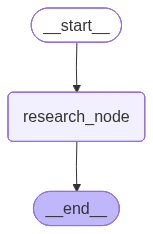

In [13]:
# ==========================================
# Visualize Graph Structure
# ==========================================

from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [14]:
# ==========================================
# Understand State Updates
# ==========================================

result = graph.invoke({"user_query": "Explain Agentic AI"})

print("\nUpdated State:\n")
print(result)


--- Research Node Executed ---

Updated State:

{'user_query': 'Explain Agentic AI', 'research_notes': 'Research completed for: Explain Agentic AI'}
